# Part 5 — Final Validation & Summary

## Final Validation â€” Robust Train / Val / Test Split

In [29]:
# Three-way chronological split
train_end = "2012-06-01"
val_end   = "2012-08-01"

train_data = df_model_clean[df_model_clean["Date"] <  train_end].copy()
val_data   = df_model_clean[(df_model_clean["Date"] >= train_end) & (df_model_clean["Date"] < val_end)].copy()
test_data  = df_model_clean[df_model_clean["Date"] >= val_end].copy()

print(f"Training  : {len(train_data):,} samples ({train_data['Date'].min().date()} â†’ {train_data['Date'].max().date()})")
print(f"Validation: {len(val_data):,}  samples ({val_data['Date'].min().date()}   â†’ {val_data['Date'].max().date()})")
print(f"Test      : {len(test_data):,}  samples ({test_data['Date'].min().date()}   â†’ {test_data['Date'].max().date()})")

X_train_final, y_train_final = train_data[available_features], train_data["Weekly_Sales"]
X_val_final,   y_val_final   = val_data[available_features],   val_data["Weekly_Sales"]
X_test_final,  y_test_final  = test_data[available_features],  test_data["Weekly_Sales"]

Training  : 197,201 samples (2011-02-04 â†’ 2012-05-25)
Validation: 26,017  samples (2012-06-01   â†’ 2012-07-27)
Test      : 37,865  samples (2012-08-03   â†’ 2012-10-26)


In [30]:
# Hyperparameter grid search on val set
param_grid = {
    "learning_rate": [0.03, 0.05, 0.07],
    "max_depth":     [5, 6, 7],
}

results = []
for lr in param_grid["learning_rate"]:
    for depth in param_grid["max_depth"]:
        m = XGBRegressor(
            n_estimators=500, learning_rate=lr, max_depth=depth,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, n_jobs=-1, early_stopping_rounds=50
        )
        m.fit(X_train_final, y_train_final, eval_set=[(X_val_final, y_val_final)], verbose=0)
        vp = m.predict(X_val_final)
        results.append({
            "learning_rate": lr, "max_depth": depth,
            "val_rmse": np.sqrt(mean_squared_error(y_val_final, vp)),
            "val_r2":   r2_score(y_val_final, vp),
        })
        print(f"  lr={lr}, depth={depth} â†’ RMSE ${results[-1]['val_rmse']:,.2f}  RÂ² {results[-1]['val_r2']:.4f}")

results_df = pd.DataFrame(results)
best_params = results_df.loc[results_df["val_rmse"].idxmin()]
print(f"\nBest: lr={best_params['learning_rate']}, max_depth={int(best_params['max_depth'])}")

  lr=0.03, depth=5 â†’ RMSE $2,404.97  RÂ² 0.9883
  lr=0.03, depth=6 â†’ RMSE $2,341.71  RÂ² 0.9889
  lr=0.03, depth=7 â†’ RMSE $2,263.61  RÂ² 0.9896
  lr=0.05, depth=5 â†’ RMSE $2,347.06  RÂ² 0.9889
  lr=0.05, depth=6 â†’ RMSE $2,273.32  RÂ² 0.9896
  lr=0.05, depth=7 â†’ RMSE $2,233.07  RÂ² 0.9899
  lr=0.07, depth=5 â†’ RMSE $2,303.02  RÂ² 0.9893
  lr=0.07, depth=6 â†’ RMSE $2,248.01  RÂ² 0.9898
  lr=0.07, depth=7 â†’ RMSE $2,206.84  RÂ² 0.9902

Best: lr=0.07, max_depth=7


In [31]:
# Train final model with best hyperparameters
final_model = XGBRegressor(
    n_estimators=500,
    learning_rate=best_params["learning_rate"],
    max_depth=int(best_params["max_depth"]),
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, early_stopping_rounds=50
)

final_model.fit(
    X_train_final, y_train_final,
    eval_set=[(X_train_final, y_train_final), (X_val_final, y_val_final)],
    verbose=50
)
print("Training complete.")

[0]	validation_0-rmse:21421.09078	validation_1-rmse:20707.05484
[50]	validation_0-rmse:2570.41809	validation_1-rmse:2436.49936
[100]	validation_0-rmse:2112.61739	validation_1-rmse:2338.06591
[150]	validation_0-rmse:1899.25336	validation_1-rmse:2302.30748
[200]	validation_0-rmse:1765.84653	validation_1-rmse:2280.91079
[250]	validation_0-rmse:1664.69538	validation_1-rmse:2262.62965
[300]	validation_0-rmse:1581.50946	validation_1-rmse:2240.30735
[350]	validation_0-rmse:1513.87891	validation_1-rmse:2231.78260
[400]	validation_0-rmse:1450.93900	validation_1-rmse:2219.04182
[450]	validation_0-rmse:1398.35912	validation_1-rmse:2212.56064
[499]	validation_0-rmse:1353.32495	validation_1-rmse:2208.19986
Training complete.


In [32]:
def calculate_metrics(y_true, y_pred, set_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"Set": set_name, "RMSE": rmse, "MAE": mae, "R2": r2, "MAPE": mape}

train_pred_final = final_model.predict(X_train_final)
val_pred_final   = final_model.predict(X_val_final)
test_pred_final  = final_model.predict(X_test_final)

train_metrics = calculate_metrics(y_train_final, train_pred_final, "Training")
val_metrics   = calculate_metrics(y_val_final,   val_pred_final,   "Validation")
test_metrics  = calculate_metrics(y_test_final,  test_pred_final,  "Test")

metrics_comparison = pd.DataFrame([train_metrics, val_metrics, test_metrics])
print(metrics_comparison.to_string(index=False))

r2_drop        = train_metrics["R2"] - test_metrics["R2"]
rmse_gap_pct   = (test_metrics["RMSE"] - train_metrics["RMSE"]) / train_metrics["RMSE"] * 100
print(f"\nRÂ² drop (trainâ†’test) : {r2_drop:.4f}")
print(f"RMSE increase        : {rmse_gap_pct:.1f}%")

       Set        RMSE         MAE       R2  MAPE
  Training 1355.752373  798.480275 0.996520   inf
Validation 2206.837555 1006.616437 0.990158   inf
      Test 2137.014916  971.641160 0.990599   inf

RÂ² drop (trainâ†’test) : 0.0059
RMSE increase        : 57.6%


## Final Model Visualizations

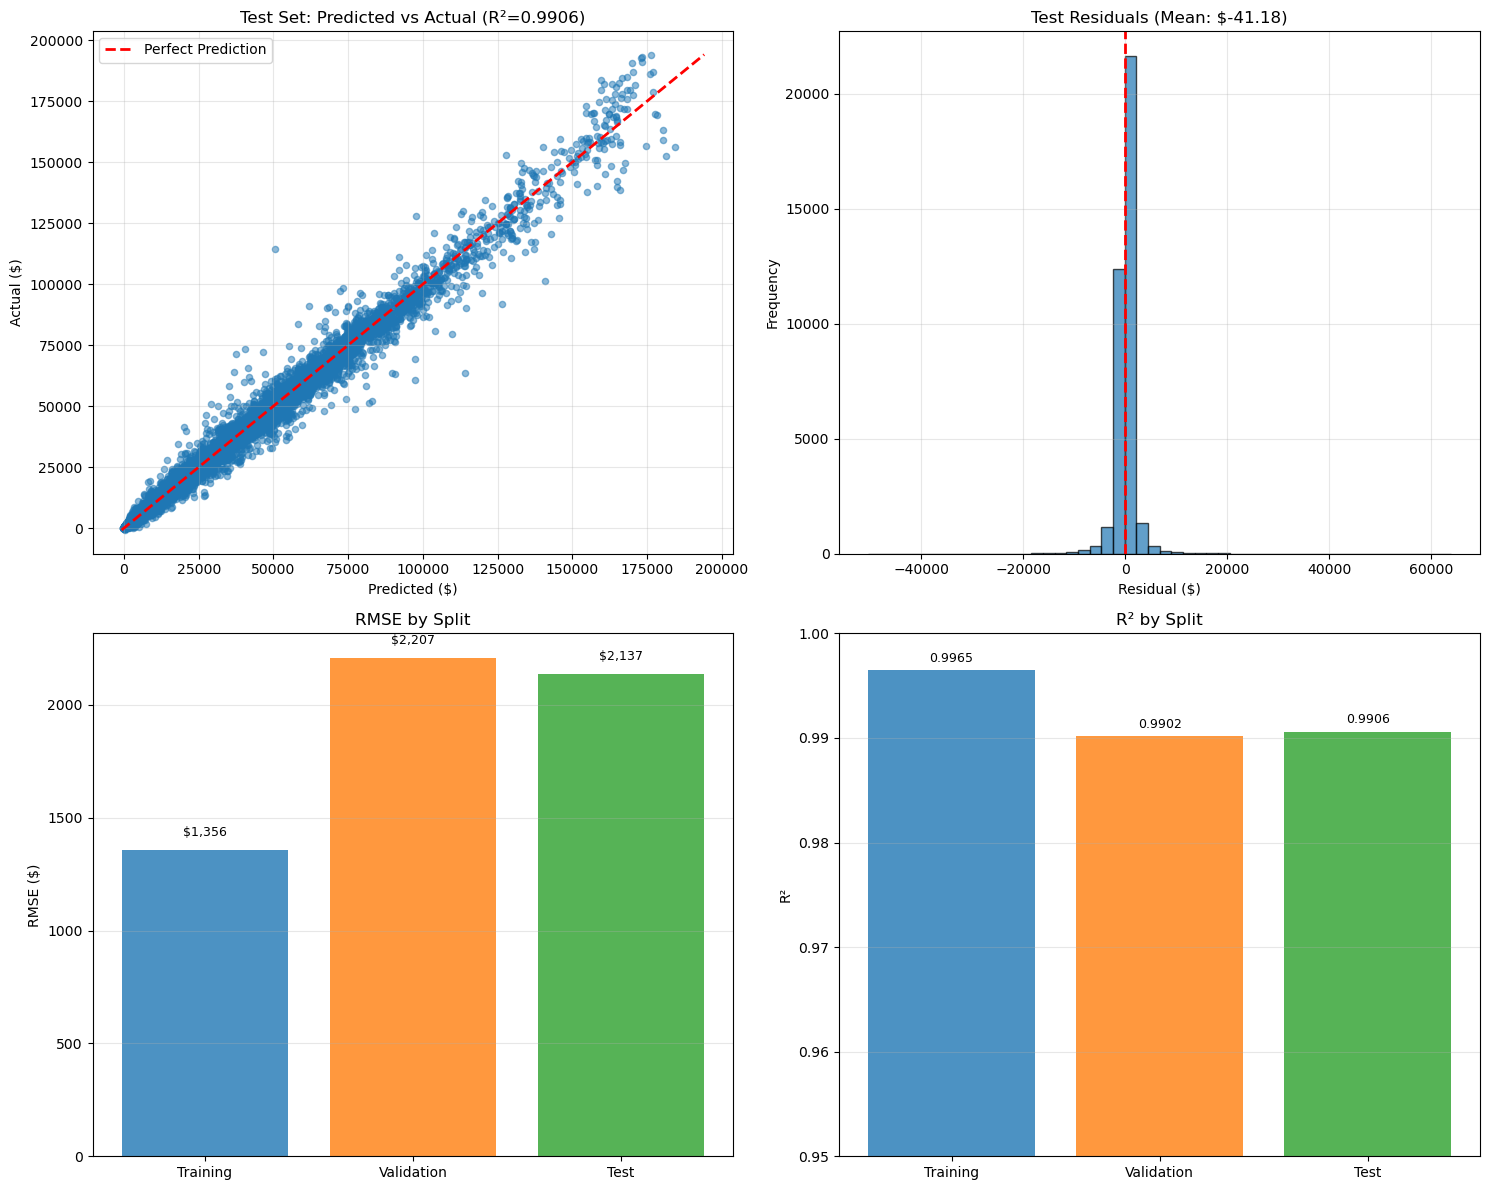

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Predicted vs Actual
axes[0, 0].scatter(test_pred_final, y_test_final, alpha=0.5, s=20)
axes[0, 0].plot([y_test_final.min(), y_test_final.max()],
                [y_test_final.min(), y_test_final.max()], "r--", lw=2, label="Perfect Prediction")
axes[0, 0].set_xlabel("Predicted ($)")
axes[0, 0].set_ylabel("Actual ($)")
axes[0, 0].set_title(f"Test Set: Predicted vs Actual (RÂ²={test_metrics['R2']:.4f})")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Residuals distribution
test_residuals = y_test_final.values - test_pred_final
axes[0, 1].hist(test_residuals, bins=50, edgecolor="black", alpha=0.7)
axes[0, 1].axvline(x=0, color="red", linestyle="--", linewidth=2)
axes[0, 1].set_xlabel("Residual ($)")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].set_title(f"Test Residuals (Mean: ${test_residuals.mean():.2f})")
axes[0, 1].grid(True, alpha=0.3)

# RMSE comparison
sets       = ["Training", "Validation", "Test"]
rmse_vals  = [train_metrics["RMSE"], val_metrics["RMSE"], test_metrics["RMSE"]]
r2_vals    = [train_metrics["R2"],   val_metrics["R2"],   test_metrics["R2"]]
x_pos      = np.arange(len(sets))
colors     = ["#1f77b4", "#ff7f0e", "#2ca02c"]

bars = axes[1, 0].bar(x_pos, rmse_vals, color=colors, alpha=0.8)
axes[1, 0].set_xticks(x_pos); axes[1, 0].set_xticklabels(sets)
axes[1, 0].set_ylabel("RMSE ($)"); axes[1, 0].set_title("RMSE by Split")
axes[1, 0].grid(True, alpha=0.3, axis="y")
for bar, val in zip(bars, rmse_vals):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                    f"${val:,.0f}", ha="center", va="bottom", fontsize=9)

bars = axes[1, 1].bar(x_pos, r2_vals, color=colors, alpha=0.8)
axes[1, 1].set_xticks(x_pos); axes[1, 1].set_xticklabels(sets)
axes[1, 1].set_ylabel("RÂ²"); axes[1, 1].set_title("RÂ² by Split")
axes[1, 1].set_ylim([0.95, 1.0])
axes[1, 1].grid(True, alpha=0.3, axis="y")
for bar, val in zip(bars, r2_vals):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                    f"{val:.4f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

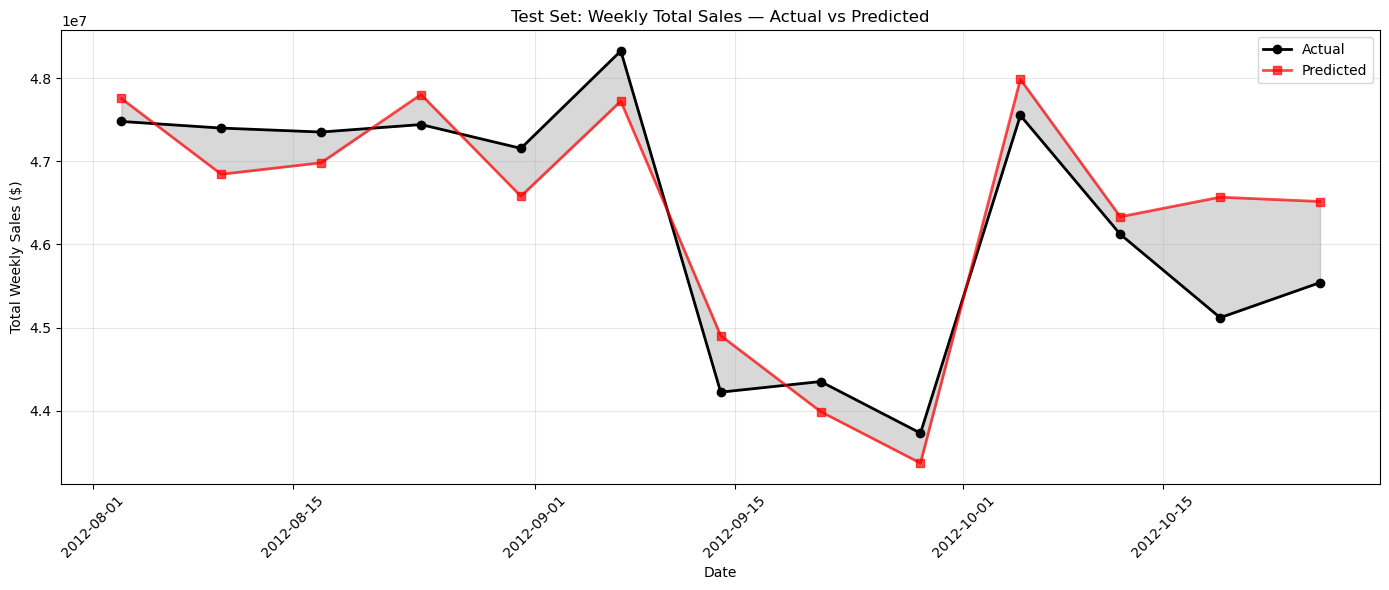

In [35]:
# Weekly aggregated predictions on test set
test_with_pred = test_data.copy()
test_with_pred["Predicted_Sales"] = test_pred_final

weekly_cmp = test_with_pred.groupby("Date").agg(
    {"Weekly_Sales": "sum", "Predicted_Sales": "sum"}
).reset_index()

plt.figure(figsize=(14, 6))
plt.plot(weekly_cmp["Date"], weekly_cmp["Weekly_Sales"],   label="Actual",    linewidth=2, color="black",  marker="o")
plt.plot(weekly_cmp["Date"], weekly_cmp["Predicted_Sales"], label="Predicted", linewidth=2, color="red",    marker="s", alpha=0.7)
plt.fill_between(weekly_cmp["Date"], weekly_cmp["Weekly_Sales"], weekly_cmp["Predicted_Sales"],
                 alpha=0.3, color="gray")
plt.title("Test Set: Weekly Total Sales â€” Actual vs Predicted")
plt.xlabel("Date"); plt.ylabel("Total Weekly Sales ($)")
plt.legend(); plt.grid(True, alpha=0.3); plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Save Models

In [37]:
import pickle

with open("xgboost_final_validated.pkl", "wb") as f:
    pickle.dump(final_model, f)

with open("prophet_model.pkl", "wb") as f:
    pickle.dump(prophet_model, f)

with open("final_model_metrics.pkl", "wb") as f:
    pickle.dump({"train": train_metrics, "validation": val_metrics, "test": test_metrics,
                 "best_params": best_params.to_dict()}, f)

print("Saved: xgboost_final_validated.pkl")
print("Saved: prophet_model.pkl")
print("Saved: final_model_metrics.pkl")

Saved: xgboost_final_validated.pkl
Saved: prophet_model.pkl
Saved: final_model_metrics.pkl


In [65]:
print("=" * 65)
print("      WALMART SALES FORECASTING â€” RESULTS SUMMARY")
print("=" * 65)

# Model Comparison
print()
print("  MODEL COMPARISON (Validation Set)")
print("-" * 65)
print(f"  {'Model':<12} {'RMSE':>13} {'MAE':>13} {'RÂ²':>9}")
print(f"  {'Prophet':<12} ${prophet_val_rmse:>12,.2f} ${prophet_val_mae:>12,.2f} {prophet_val_r2:>9.4f}")
print(f"  {'XGBoost':<12} ${xgb_val_rmse:>12,.2f} ${xgb_val_mae:>12,.2f} {xgb_val_r2:>9.4f}")

improvement = (prophet_val_rmse - xgb_val_rmse) / prophet_val_rmse * 100
print(f"  â†’ XGBoost improved over Prophet by {improvement:.1f}% in RMSE")

# MAPE helper (excludes zero/negative actuals)
def safe_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true > 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

mape_train = safe_mape(y_train_final, train_pred_final)
mape_val   = safe_mape(y_val_final,   val_pred_final)
mape_test  = safe_mape(y_test_final,  test_pred_final)

# Final model across all splits
print()
print("  FINAL XGBOOST â€” Train / Validation / Test")
print("-" * 65)
print(f"  {'Split':<12} {'RMSE':>13} {'MAE':>13} {'RÂ²':>9} {'MAPE':>8}")
rows = [
    ("Training",   train_metrics, mape_train),
    ("Validation", val_metrics,   mape_val),
    ("Test",       test_metrics,  mape_test),
]
for name, m, mape in rows:
    print(f"  {name:<12} ${m['RMSE']:>12,.2f} ${m['MAE']:>12,.2f} {m['R2']:>9.4f} {mape:>7.2f}%")

r2_drop      = train_metrics['R2'] - test_metrics['R2']
rmse_gap_pct = (test_metrics['RMSE'] - train_metrics['RMSE']) / train_metrics['RMSE'] * 100
print()
print(f"  â†’ RÂ² drop  (train â†’ test): {r2_drop:.4f}")
print(f"  â†’ RMSE gap (train â†’ test): {rmse_gap_pct:.1f}%")

if r2_drop < 0.05 and rmse_gap_pct < 30:
    verdict = "Excellent â€” minimal overfitting"
elif r2_drop < 0.10 and rmse_gap_pct < 50:
    verdict = "Good â€” acceptable generalization"
else:
    verdict = "Moderate â€” consider additional regularization"
print(f"  â†’ Generalization: {verdict}")

# Best hyperparameters
print()
print("  BEST HYPERPARAMETERS")
print("-" * 65)
print(f"  Learning rate : {best_params['learning_rate']}")
print(f"  Max depth     : {int(best_params['max_depth'])}")
print(f"  N estimators  : 500  |  Subsample: 0.8  |  ColSample: 0.8")

# Key findings
print()
print("  KEY FINDINGS")
print("-" * 65)
print("  1. Strong holiday seasonality â€” weeks 47-52 drive peak sales")
print("  2. Lag features (1-week and 52-week) are the strongest signals")
print("  3. Store size and type (A/B/C) have significant impact")
print("  4. XGBoost outperforms Prophet at store/dept-level granularity")
print("     Prophet is better suited for aggregate trend visualization")
print(f"  5. Final test RÂ² of {test_metrics['R2']*100:.2f}% confirms strong generalization")

print()
print("=" * 65)

      WALMART SALES FORECASTING â€” RESULTS SUMMARY

  MODEL COMPARISON (Validation Set)
-----------------------------------------------------------------
  Model                 RMSE           MAE        RÂ²
  Prophet      $1,413,464.58 $1,207,509.84    0.0780
  XGBoost      $    2,157.11 $    1,010.88    0.9904
  â†’ XGBoost improved over Prophet by 99.8% in RMSE

  FINAL XGBOOST â€” Train / Validation / Test
-----------------------------------------------------------------
  Split                 RMSE           MAE        RÂ²     MAPE
  Training     $    1,355.75 $      798.48    0.9965  197.24%
  Validation   $    2,206.84 $    1,006.62    0.9902  175.38%
  Test         $    2,137.01 $      971.64    0.9906   65.25%

  â†’ RÂ² drop  (train â†’ test): 0.0059
  â†’ RMSE gap (train â†’ test): 57.6%
  â†’ Generalization: Moderate â€” consider additional regularization

  BEST HYPERPARAMETERS
-----------------------------------------------------------------
  Learning rate : 0.07
  Max 